In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# Gerekli kütüphane kurulumu 
!pip install --upgrade git+https://github.com/zekikus/MedSegBench.git


  Cloning https://github.com/zekikus/MedSegBench.git to /tmp/pip-req-build-1dyb1251
  Running command git clone --filter=blob:none --quiet https://github.com/zekikus/MedSegBench.git /tmp/pip-req-build-1dyb1251
  Resolved https://github.com/zekikus/MedSegBench.git to commit 54fde021831ca89ab770096b9c2bec7de1c91957
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━

In [3]:
# Gerekli kütüphaneler
import torch
from tqdm import tqdm
from torch.utils.data import DataLoader
from torchvision import transforms
from medsegbench import Isic2018MSBench

# Cihaz tanımı
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Eğitim verisi için augmentasyon
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

# Val ve test verisi için sade transform
val_test_transform = transforms.ToTensor()

# Datasetler
train_dataset = Isic2018MSBench(split="train", size=256, transform=train_transform, download=True)
val_dataset = Isic2018MSBench(split="val", size=256, transform=val_test_transform, download=True)
test_dataset = Isic2018MSBench(split="test", size=256, transform=val_test_transform, download=True)


# DataLoader'lar
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=2)


Device: cuda


100%|██████████| 531M/531M [00:24<00:00, 21.8MB/s]  


In [4]:
import torch.nn as nn
import torch.optim as optim

# DoubleConv bloğu (Conv → ReLU → Conv → ReLU)
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

# Basit U-Net tanımı
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()

        self.down1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.output = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(self.pool1(d1))
        bn = self.bottleneck(self.pool2(d2))
        up2 = self.up2(bn)
        up2 = torch.cat([up2, d2], dim=1)
        up2 = self.conv2(up2)
        up1 = self.up1(up2)
        up1 = torch.cat([up1, d1], dim=1)
        up1 = self.conv1(up1)
        return torch.sigmoid(self.output(up1))

# Modeli oluştur
model = UNet().to(device)

# Kayıp fonksiyonu: BCE + Dice Loss
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, inputs, targets):
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        intersection = (inputs * targets).sum()
        dice = (2. * intersection + self.smooth) / (inputs.sum() + targets.sum() + self.smooth)
        return 1 - dice

bce_loss = nn.BCELoss()
dice_loss = DiceLoss()

def combined_loss(pred, target):
    return bce_loss(pred, target) + dice_loss(pred, target)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [5]:
from torch.utils.tensorboard import SummaryWriter
import torchvision
import numpy as np

# TensorBoard başlat
writer = SummaryWriter(log_dir="runs/unet_augmented")

num_epochs = 150
best_val_loss = float('inf')
save_path = "best_unet_model.pt"
patience = 30
no_improve_epochs = 0  # Early stopping sayacı

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
        images = images.float().to(device)
        masks = masks.unsqueeze(1).float().to(device) / 255.0

        outputs = model(images)
        loss = combined_loss(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = (outputs > 0.5).float()
        train_correct += (preds == masks).float().sum().item()
        train_total += masks.numel()

    avg_train_loss = train_loss / len(train_loader)
    train_accuracy = train_correct / train_total

    # === VALIDASYON ===
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
            images = images.float().to(device)
            masks = masks.unsqueeze(1).float().to(device) / 255.0

            outputs = model(images)
            loss = combined_loss(outputs, masks)
            val_loss += loss.item()

            preds = (outputs > 0.5).float()
            val_correct += (preds == masks).float().sum().item()
            val_total += masks.numel()

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = val_correct / val_total

    print(f"[{epoch+1}/{num_epochs}] Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"                     Train Acc:  {train_accuracy:.4f} | Val Acc:  {val_accuracy:.4f}")

    # === TensorBoard logları ===
    writer.add_scalar("Loss/Train", avg_train_loss, epoch + 1)
    writer.add_scalar("Loss/Val", avg_val_loss, epoch + 1)
    writer.add_scalar("Accuracy/Train", train_accuracy, epoch + 1)
    writer.add_scalar("Accuracy/Val", val_accuracy, epoch + 1)

    # Görsel loglama
    images_cpu = images.cpu()
    outputs_cpu = outputs.cpu()
    masks_cpu = masks.cpu()
    predicted = (outputs_cpu > 0.5).float()

    grid = torchvision.utils.make_grid([
        images_cpu[0],
        predicted[0].repeat(3, 1, 1),
        masks_cpu[0].repeat(3, 1, 1)
    ])
    writer.add_image("Input-Predicted-GroundTruth", grid, epoch + 1)

    # === Early stopping kontrolü ===
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), save_path)
        print("✅ Yeni en iyi model kaydedildi.")
        no_improve_epochs = 0  # sıfırla
    else:
        no_improve_epochs += 1
        print(f"📉 Val loss iyileşmedi. Sabit kalan epoch sayısı: {no_improve_epochs}")

        if no_improve_epochs >= patience:
            print(f"🛑 Erken durdurma: Son {patience} epoch'tur val loss iyileşmedi.")
            break


2025-05-19 19:17:26.693138: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747682246.884033      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747682246.939570      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Epoch 1/150 - Validation: 100%|██████████| 13/13 [00:00<00:00, 17.26it/s]


[1/150] Train Loss: 1.1015 | Val Loss: 0.9055
                     Train Acc:  0.7998 | Val Acc:  0.8184
✅ Yeni en iyi model kaydedildi.


Epoch 2/150 - Validation: 100%|██████████| 13/13 [00:00<00:00, 17.26it/s]


[2/150] Train Loss: 0.9330 | Val Loss: 0.7974
                     Train Acc:  0.8389 | Val Acc:  0.8492
✅ Yeni en iyi model kaydedildi.


Epoch 3/150 - Validation: 100%|██████████| 13/13 [00:00<00:00, 17.34it/s]


...

[62/150] Train Loss: 0.6066 | Val Loss: 0.6164
                     Train Acc:  0.8931 | Val Acc:  0.8601
📉 Val loss iyileşmedi. Sabit kalan epoch sayısı: 28


Epoch 63/150 - Validation: 100%|██████████| 13/13 [00:00<00:00, 16.99it/s]


[63/150] Train Loss: 0.6091 | Val Loss: 0.6057
                     Train Acc:  0.8927 | Val Acc:  0.8657
📉 Val loss iyileşmedi. Sabit kalan epoch sayısı: 29


Epoch 64/150 - Validation: 100%|██████████| 13/13 [00:00<00:00, 17.08it/s]

[64/150] Train Loss: 0.6028 | Val Loss: 0.5740
                     Train Acc:  0.8939 | Val Acc:  0.8754
📉 Val loss iyileşmedi. Sabit kalan epoch sayısı: 30
🛑 Erken durdurma: Son 30 epoch'tur val loss iyileşmedi.


In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, jaccard_score
import numpy as np

# En iyi modeli yükle
model.load_state_dict(torch.load("best_unet_model.pt"))
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc="Testing"):
        images = images.float().to(device)
        masks = masks.unsqueeze(1).float().to(device) / 255.0

        outputs = model(images)
        preds = (outputs > 0.5).float()

        all_preds.extend(preds.cpu().numpy().reshape(-1))
        all_targets.extend(masks.cpu().numpy().reshape(-1))

# NumPy array'e çevir
all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

# Metrikleri hesapla
acc = accuracy_score(all_targets, all_preds)
prec = precision_score(all_targets, all_preds)
rec = recall_score(all_targets, all_preds)
f1 = f1_score(all_targets, all_preds)
iou = jaccard_score(all_targets, all_preds)

print(f"Test Accuracy:  {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall:    {rec:.4f}")
print(f"Test F1 Score:  {f1:.4f}")
print(f"Test IoU:       {iou:.4f}")


Testing: 100%|██████████| 125/125 [00:14<00:00,  8.36it/s]


Test Accuracy:  0.8625
Test Precision: 0.7695
Test Recall:    0.7262
Test F1 Score:  0.7472
Test IoU:       0.5964


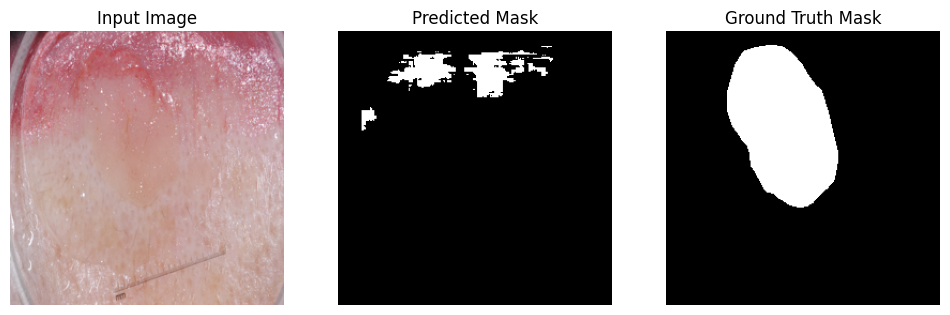

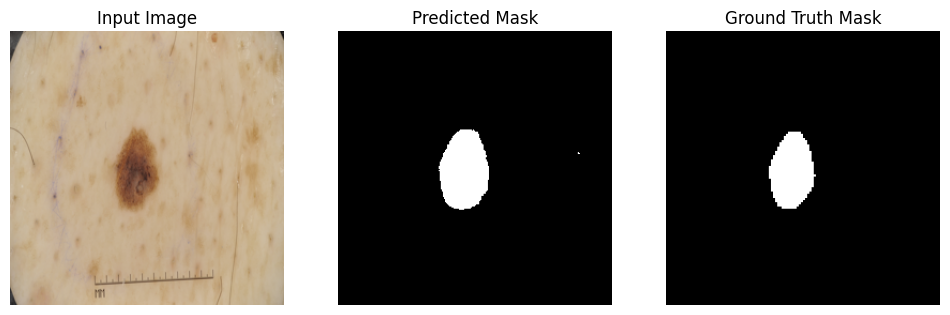

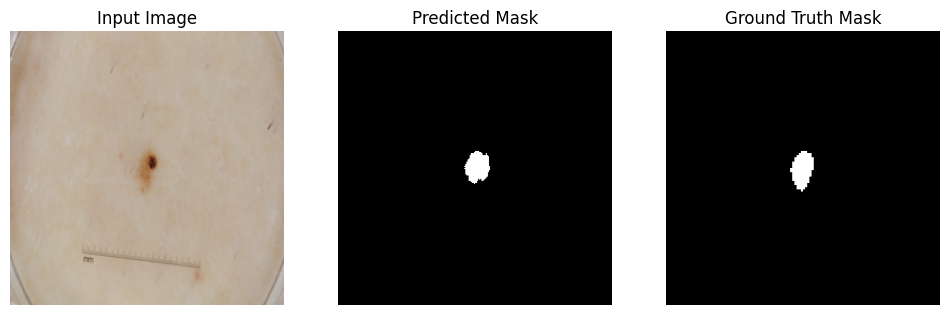

In [8]:
import matplotlib.pyplot as plt

# Modeli evaluation moduna al
model.eval()

# İlk batch'ten 3 örnek alalım
with torch.no_grad():
    images, masks = next(iter(test_loader))
    images = images.float().to(device)
    masks = masks.unsqueeze(1).float().to(device) / 255.0
    outputs = model(images)
    preds = (outputs > 0.5).float()

# CPU'ya al
images = images.cpu().numpy()
masks = masks.cpu().numpy()
preds = preds.cpu().numpy()

# 3 örnek çiz
for i in range(3):
    plt.figure(figsize=(12, 4))

    # Input
    plt.subplot(1, 3, 1)
    plt.imshow(np.transpose(images[i], (1, 2, 0)))
    plt.title("Input Image")
    plt.axis("off")

    # Predicted
    plt.subplot(1, 3, 2)
    plt.imshow(preds[i][0], cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    # Ground Truth
    plt.subplot(1, 3, 3)
    plt.imshow(masks[i][0], cmap="gray")
    plt.title("Ground Truth Mask")
    plt.axis("off")

    plt.show()


In [10]:
%load_ext tensorboard
%tensorboard --logdir runs/unet_augmented

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 1186), started 0:00:08 ago. (Use '!kill 1186' to kill it.)

<IPython.core.display.Javascript object>

In [11]:
!zip -r tensorboard_logs.zip runs


  adding: runs/ (stored 0%)
  adding: runs/unet_augmented/ (stored 0%)
  adding: runs/unet_augmented/events.out.tfevents.1747682258.698d2899fa63.35.0 (deflated 0%)
